# 02. Filter high-quality tickers

Filter `config.FILTERED_TICKERS` (59 tickers) down to the strategy universe for Monday-close -> Friday-close weekly options selling.

**Hard filters (all applied together):**

1. **Weekly Friday expirations**: >= `90%` of the last 26 Monday snapshots have an options expiration with DTE in `(3, 5)` that lands on Friday (or Thursday during Good-Friday weeks). Rules out monthly-only names.
2. **Open interest**: median total OI across near-term contracts (DTE `(0, 14)`) >= `10,000`.
3. **Volume**: median total near-term volume >= `500`.
4. **Relative bid-ask spread**: median `(ask - bid) / mark` on sellable contracts (|delta| in `(0.15, 0.45)`, DTE `(3, 7)`, mark >= $0.05) <= `0.2`. Caps execution slippage on entry.
5. **Quote presence**: fraction of sellable contracts with `bid > 0` >= `0.85`. Rules out "no-bid" chains where you literally can't sell.
6. **Bid depth**: median `bid_size` on sellable contracts >= `5` contracts.
7. **Underlying price**: last close >= `$3`. Sub-$3 names have penny-wide spreads that dominate the option mid.

All thresholds are constants at the top of cell 1; tweak there and re-run.


In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd

from config import FILTERED_TICKERS


RECENT_MONDAYS = 26
DTE_WEEK_RANGE = (3, 5)
DTE_NEAR_TERM = (0, 14)
DTE_SELLABLE = (3, 7)
DELTA_SELLABLE = (0.15, 0.45)
MARK_FLOOR = 0.05

WEEKLY_MIN_PCT = 90.0
OI_MIN = 10_000
VOL_MIN = 500
SPREAD_MAX = 0.20
BID_NONZERO_MIN = 0.85
BID_SIZE_MIN = 5
PRICE_MIN = 3.0

DATE_RE = re.compile(r"_(\d{4}-\d{2}-\d{2})\.csv$")

## Per-ticker scan

For each ticker, take the last 26 Monday option-chain snapshots and compute:

- weekly-Friday availability (structural)
- total near-term OI / volume (universe liquidity)
- relative bid-ask spread, non-zero-bid rate, bid depth on the contracts you'd actually sell
- last underlying close (from `daily_alpha`)


In [2]:
def last_close(ticker):
    p = Path("data/daily_alpha") / f"{ticker}.csv"
    if not p.exists():
        return None
    df = pd.read_csv(p, usecols=["date", "close"])
    return float(df["close"].iloc[-1])


def per_ticker_stats(ticker):
    tdir = Path("data/options_alpha") / ticker
    if not tdir.is_dir():
        return None
    mondays = []
    for f in tdir.iterdir():
        m = DATE_RE.search(f.name)
        if not m:
            continue
        snap = pd.Timestamp(m.group(1))
        if snap.weekday() == 0:
            mondays.append((snap, f))
    mondays.sort()
    recent = mondays[-RECENT_MONDAYS:] if len(mondays) > RECENT_MONDAYS else mondays
    if not recent:
        return None

    n_weekly_fri = 0
    oi_near, vol_near = [], []
    spread_rel, bid_nz, bid_size = [], [], []

    for snap, f in recent:
        df = pd.read_csv(
            f,
            usecols=[
                "expiration",
                "open_interest",
                "volume",
                "delta",
                "bid",
                "ask",
                "mark",
                "bid_size",
            ],
        )
        df["expiration"] = pd.to_datetime(df["expiration"])
        df["dte"] = (df["expiration"] - snap).dt.days

        near = df[df["dte"].between(*DTE_WEEK_RANGE)]
        if near["expiration"].dt.weekday.isin([3, 4]).any():
            n_weekly_fri += 1

        near_term = df[df["dte"].between(*DTE_NEAR_TERM)]
        if len(near_term):
            oi_near.append(int(near_term["open_interest"].sum()))
            vol_near.append(int(near_term["volume"].sum()))

        sellable = df[
            df["dte"].between(*DTE_SELLABLE)
            & df["delta"].abs().between(*DELTA_SELLABLE)
            & (df["mark"] >= MARK_FLOOR)
        ]
        if len(sellable):
            rel = (sellable["ask"] - sellable["bid"]) / sellable["mark"]
            spread_rel.append(float(rel.median()))
            bid_nz.append(float((sellable["bid"] > 0).mean()))
            bid_size.append(float(sellable["bid_size"].median()))

    def _med(xs):
        return float(pd.Series(xs).median()) if xs else None

    return {
        "ticker": ticker,
        "last_close": last_close(ticker),
        "weekly_fri_pct": round(100 * n_weekly_fri / len(recent), 1),
        "median_near_oi": int(pd.Series(oi_near).median()) if oi_near else 0,
        "median_near_vol": int(pd.Series(vol_near).median()) if vol_near else 0,
        "median_spread_rel": round(_med(spread_rel), 3) if spread_rel else None,
        "bid_nonzero_rate": round(_med(bid_nz), 3) if bid_nz else None,
        "median_bid_size": int(_med(bid_size)) if bid_size else None,
    }


rows = [per_ticker_stats(t) for t in FILTERED_TICKERS]
rows = [r for r in rows if r]
stats = pd.DataFrame(rows)

stats["pass_weekly"] = stats["weekly_fri_pct"] >= WEEKLY_MIN_PCT
stats["pass_oi"] = stats["median_near_oi"] >= OI_MIN
stats["pass_vol"] = stats["median_near_vol"] >= VOL_MIN
stats["pass_spread"] = stats["median_spread_rel"].fillna(9.99) <= SPREAD_MAX
stats["pass_bid_nz"] = stats["bid_nonzero_rate"].fillna(0) >= BID_NONZERO_MIN
stats["pass_bid_size"] = stats["median_bid_size"].fillna(0) >= BID_SIZE_MIN
stats["pass_price"] = stats["last_close"].fillna(0) >= PRICE_MIN
stats["pass_all"] = (
    stats["pass_weekly"]
    & stats["pass_oi"]
    & stats["pass_vol"]
    & stats["pass_spread"]
    & stats["pass_bid_nz"]
    & stats["pass_bid_size"]
    & stats["pass_price"]
)

stats_sorted = stats.sort_values(
    ["pass_all", "median_spread_rel", "median_near_oi"],
    ascending=[False, True, False],
).reset_index(drop=True)
print(f"scanned {len(stats)} tickers; {stats['pass_all'].sum()} pass all filters")
stats_sorted

scanned 59 tickers; 35 pass all filters


,ticker,last_close,weekly_fri_pct,median_near_oi,median_near_vol,median_spread_rel,bid_nonzero_rate,median_bid_size,pass_weekly,pass_oi,pass_vol,pass_spread,pass_bid_nz,pass_bid_size,pass_price,pass_all
0,NVDA,177.3900,100.0,1759188,1661630,0.015,1.0,16,True,True,True,True,True,True,True,True
1,TSLA,360.5900,100.0,1050186,1578309,0.015,1.0,18,True,True,True,True,True,True,True,True
2,AMD,217.5000,100.0,422556,316467,0.024,1.0,32,True,True,True,True,True,True,True,True
3,PLTR,148.4600,100.0,449696,347735,0.025,1.0,23,True,True,True,True,True,True,True,True
4,AMZN,209.7700,100.0,502224,376381,0.026,1.0,26,True,True,True,True,True,True,True,True
5,GOOGL,295.7700,100.0,263927,188800,0.029,1.0,17,True,True,True,True,True,True,True,True
6,AAPL,255.9200,100.0,463748,460221,0.030,1.0,28,True,True,True,True,True,True,True,True
7,META,574.4600,100.0,280085,285682,0.035,1.0,8,True,True,True,True,True,True,True,True
8,MSFT,373.4600,100.0,314733,180677,0.036,1.0,8,True,True,True,True,True,True,True,True
9,NFLX,98.6600,100.0,275956,150017,0.047,1.0,60,True,True,True,True,True,True,True,True


## Filter breakdown

Applied sequentially so you can see which criterion kills which ticker. Order: weekly (structural) -> OI -> volume -> spread -> bid-present -> bid-size -> price.


In [3]:
def breakdown(stats):
    alive = pd.Series(True, index=stats.index)
    print(f"Universe: {len(stats)} tickers from FILTERED_TICKERS")
    for label, thr_str, col in [
        ("weekly", f">= {WEEKLY_MIN_PCT}% Mondays", "pass_weekly"),
        ("OI", f">= {OI_MIN:,}", "pass_oi"),
        ("vol", f">= {VOL_MIN}", "pass_vol"),
        ("spread", f"<= {SPREAD_MAX}", "pass_spread"),
        ("bid_nz", f">= {BID_NONZERO_MIN}", "pass_bid_nz"),
        ("bid_size", f">= {BID_SIZE_MIN}", "pass_bid_size"),
        ("price", f">= ${PRICE_MIN:g}", "pass_price"),
    ]:
        before = int(alive.sum())
        cut_mask = alive & ~stats[col]
        cut = stats.loc[cut_mask, "ticker"].tolist()
        alive = alive & stats[col]
        after = int(alive.sum())
        print(
            f"  {label:9s} ({thr_str:<22s}) : {before:2d} -> {after:2d}  (cut {len(cut)}: {cut})"
        )
    print(f"  FINAL : {int(alive.sum())} tickers")


breakdown(stats)

Universe: 59 tickers from FILTERED_TICKERS
  weekly    (>= 90.0% Mondays      ) : 59 -> 51  (cut 8: ['ALKT', 'ARQQ', 'BYRN', 'CAI', 'KULR', 'LAC', 'LTBR', 'SLI'])
  OI        (>= 10,000             ) : 51 -> 47  (cut 4: ['DDD', 'DNUT', 'KOPN', 'QSI'])
  vol       (>= 500                ) : 47 -> 47  (cut 0: [])
  spread    (<= 0.2                ) : 47 -> 36  (cut 11: ['BE', 'CEG', 'CLOV', 'LAES', 'NFE', 'NNE', 'NVTS', 'RR', 'SERV', 'UMAC', 'ZETA'])
  bid_nz    (>= 0.85               ) : 36 -> 36  (cut 0: [])
  bid_size  (>= 5                  ) : 36 -> 36  (cut 0: [])
  price     (>= $3                 ) : 36 -> 35  (cut 1: ['BYND'])
  FINAL : 35 tickers


## Visualizing the filter

Two scatters:

- **Liquidity**: OI vs volume (near-term). Most cuts sit in the low-liquidity corner.
- **Execution quality**: spread vs last price. The new bid/ask + price filters cut the wide-spread / penny-stock quadrant.


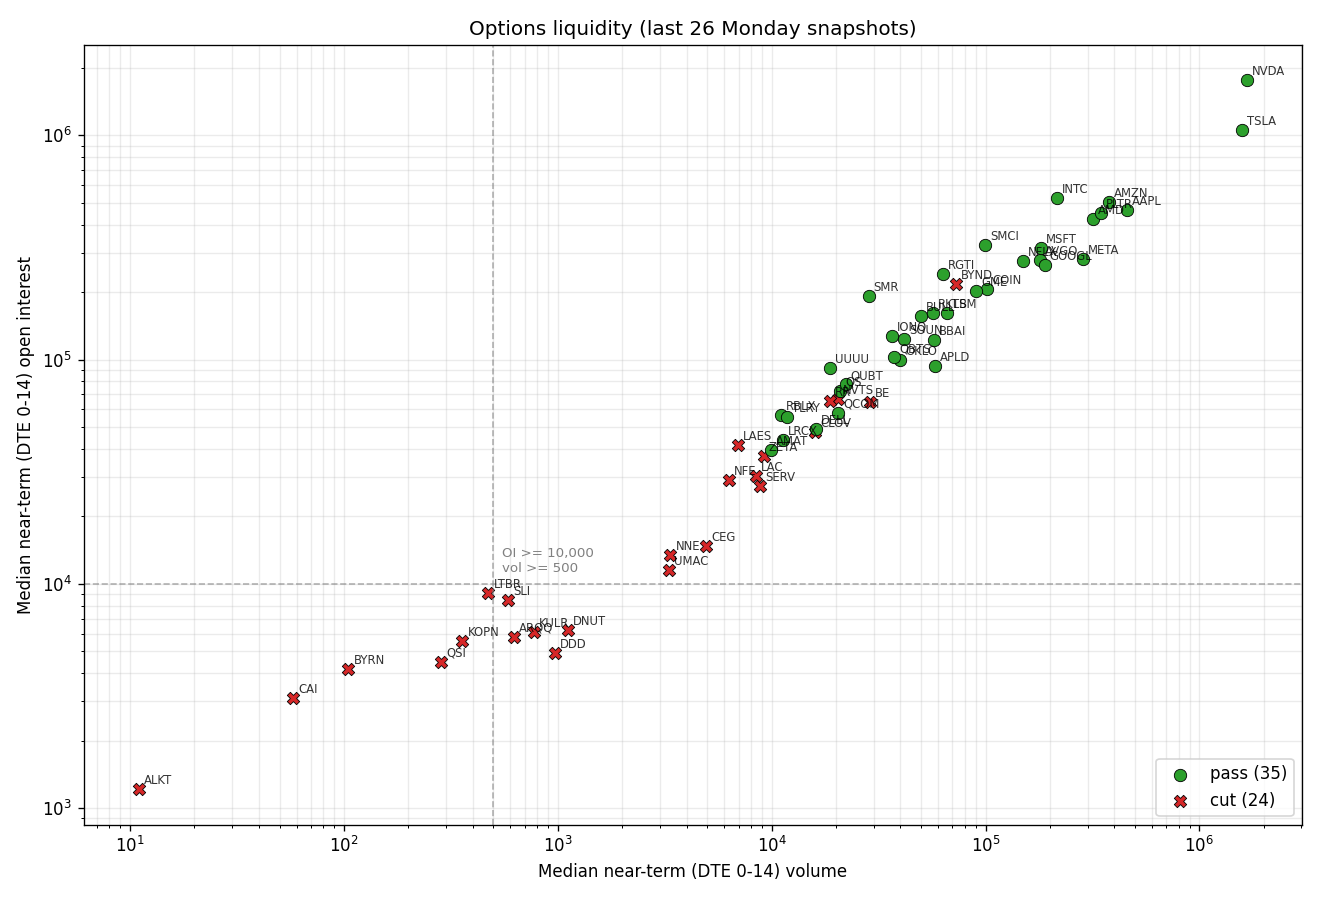

In [4]:
OUT_DIR = Path("output") / "02_filter_high_quality_ticker"
OUT_DIR.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(11, 7.5))
passed = stats[stats["pass_all"]]
cut = stats[~stats["pass_all"]]

ax.scatter(
    passed["median_near_vol"],
    passed["median_near_oi"],
    c="tab:green",
    s=55,
    label=f"pass ({len(passed)})",
    edgecolors="black",
    linewidths=0.5,
    zorder=3,
)
ax.scatter(
    cut["median_near_vol"],
    cut["median_near_oi"],
    c="tab:red",
    s=55,
    label=f"cut ({len(cut)})",
    edgecolors="black",
    linewidths=0.5,
    zorder=2,
    marker="X",
)

for _, r in stats.iterrows():
    ax.annotate(
        r["ticker"],
        (r["median_near_vol"], r["median_near_oi"]),
        fontsize=7,
        alpha=0.8,
        xytext=(3, 3),
        textcoords="offset points",
    )

ax.axhline(OI_MIN, color="gray", linestyle="--", linewidth=1, alpha=0.6)
ax.axvline(VOL_MIN, color="gray", linestyle="--", linewidth=1, alpha=0.6)
ax.text(
    VOL_MIN * 1.1,
    OI_MIN * 1.1,
    f"OI >= {OI_MIN:,}\nvol >= {VOL_MIN}",
    fontsize=8,
    color="gray",
    va="bottom",
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Median near-term (DTE 0-14) volume")
ax.set_ylabel("Median near-term (DTE 0-14) open interest")
ax.set_title(f"Options liquidity (last {RECENT_MONDAYS} Monday snapshots)")
ax.grid(True, which="both", alpha=0.25)
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(OUT_DIR / "liquidity_scatter.png", dpi=120)
plt.show()
plt.close(fig)

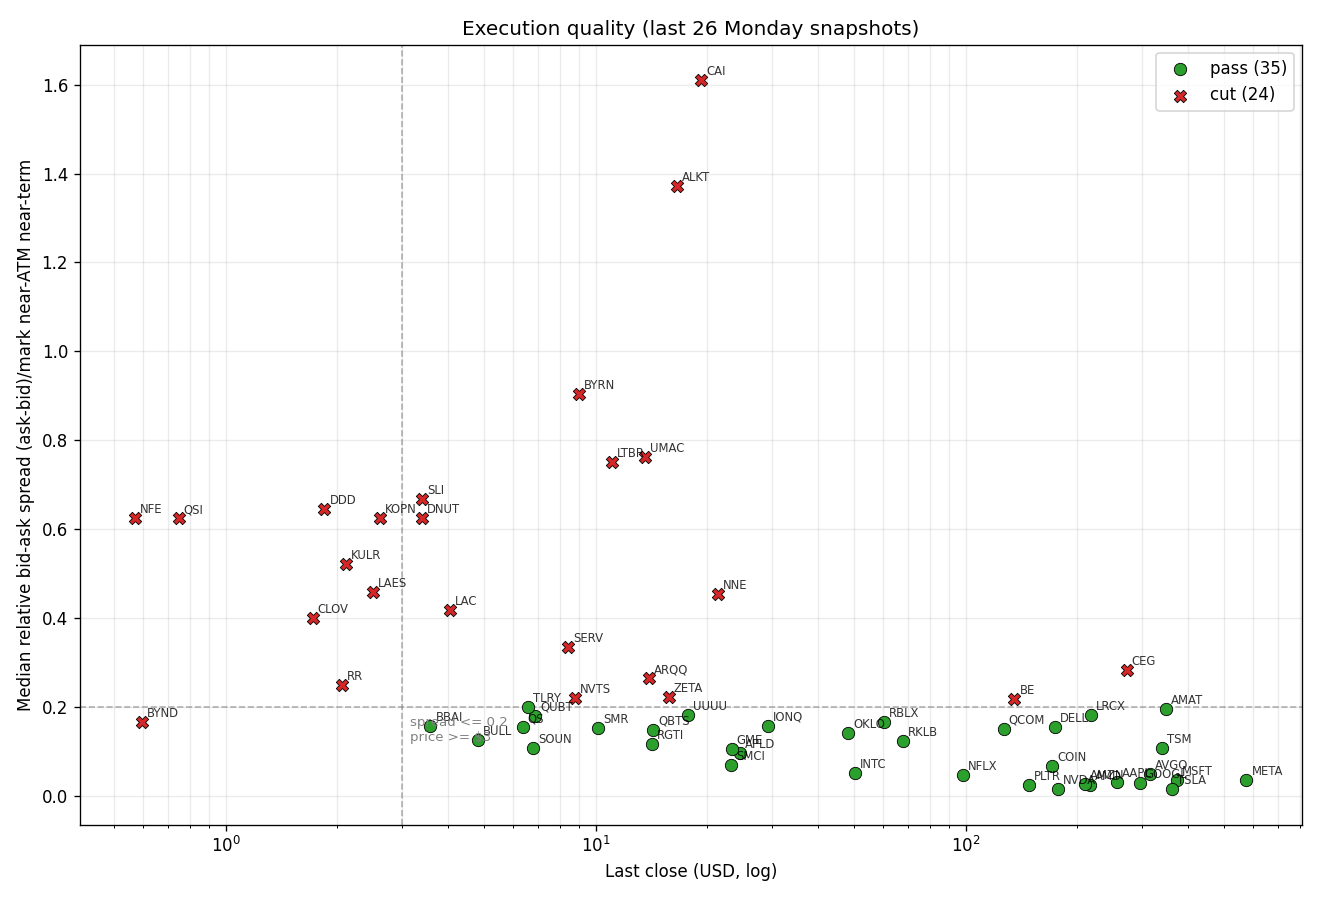

In [5]:
fig, ax = plt.subplots(figsize=(11, 7.5))
passed = stats[stats["pass_all"]]
cut = stats[~stats["pass_all"]]

ax.scatter(
    passed["last_close"],
    passed["median_spread_rel"],
    c="tab:green",
    s=55,
    label=f"pass ({len(passed)})",
    edgecolors="black",
    linewidths=0.5,
    zorder=3,
)
ax.scatter(
    cut["last_close"],
    cut["median_spread_rel"],
    c="tab:red",
    s=55,
    label=f"cut ({len(cut)})",
    edgecolors="black",
    linewidths=0.5,
    zorder=2,
    marker="X",
)

for _, r in stats.iterrows():
    if pd.isna(r["median_spread_rel"]) or pd.isna(r["last_close"]):
        continue
    ax.annotate(
        r["ticker"],
        (r["last_close"], r["median_spread_rel"]),
        fontsize=7,
        alpha=0.8,
        xytext=(3, 3),
        textcoords="offset points",
    )

ax.axhline(SPREAD_MAX, color="gray", linestyle="--", linewidth=1, alpha=0.6)
ax.axvline(PRICE_MIN, color="gray", linestyle="--", linewidth=1, alpha=0.6)
ax.text(
    PRICE_MIN * 1.05,
    SPREAD_MAX - 0.02,
    f"spread <= {SPREAD_MAX}\nprice >= ${PRICE_MIN:g}",
    fontsize=8,
    color="gray",
    va="top",
)

ax.set_xscale("log")
ax.set_xlabel("Last close (USD, log)")
ax.set_ylabel("Median (ask-bid)/mark near-ATM near-term")
ax.set_title(f"Execution quality (last {RECENT_MONDAYS} Monday snapshots)")
ax.grid(True, which="both", alpha=0.25)
ax.legend(loc="upper right")
fig.tight_layout()
fig.savefig(OUT_DIR / "quality_scatter.png", dpi=120)
plt.show()
plt.close(fig)

## Final universe

These 35 tickers pass every criterion. The list is already mirrored as `HIGH_QUALITY_TICKERS` in `config.py`.


In [6]:
hq_tickers = sorted(stats[stats["pass_all"]]["ticker"].tolist())
print(f"HIGH_QUALITY_TICKERS ({len(hq_tickers)}):")
for i in range(0, len(hq_tickers), 8):
    chunk = hq_tickers[i : i + 8]
    print("    " + ", ".join(f'"{t}"' for t in chunk) + ",")

HIGH_QUALITY_TICKERS (35):
    "AAPL", "AMAT", "AMD", "AMZN", "APLD", "AVGO", "BBAI", "BULL",
    "COIN", "DELL", "GME", "GOOGL", "INTC", "IONQ", "LRCX", "META",
    "MSFT", "NFLX", "NVDA", "OKLO", "PLTR", "QBTS", "QCOM", "QS",
    "QUBT", "RBLX", "RGTI", "RKLB", "SMCI", "SMR", "SOUN", "TLRY",
    "TSLA", "TSM", "UUUU",
